# Bagging - Diabetes Prediction

**Name:** Satheesh B  
**Roll No:** 24BAD107

## Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

## Load Dataset

In [ ]:
df = pd.read_csv("diabetes_bagging.csv")
df.head()

,Glucose,BMI,Age,BloodPressure,Insulin,Outcome
0,182,21.1,45,99,100,1
1,131,35.6,67,92,199,1
2,172,19.6,68,68,234,1
3,94,39.7,21,102,83,0
4,186,35.0,20,113,61,1


## Define Features and Target

In [ ]:
X = df.drop("Outcome", axis=1)
y = df["Outcome"]

## Train-Test Split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=1
)

## Train Decision Tree

In [ ]:
dt = DecisionTreeClassifier(max_depth=3, random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

## Train Bagging Classifier

In [ ]:
bagging = BaggingClassifier(
    estimator=DecisionTreeClassifier(max_depth=3),
    n_estimators=10,
    random_state=42
)
bagging.fit(X_train, y_train)
y_pred_bag = bagging.predict(X_test)

## Accuracy Comparison

In [ ]:
acc_dt = accuracy_score(y_test, y_pred_dt)
acc_bag = accuracy_score(y_test, y_pred_bag)

print("Decision Tree Accuracy:", acc_dt)
print("Bagging Accuracy:", acc_bag)

Decision Tree Accuracy: 1.0
Bagging Accuracy: 1.0


## Confusion Matrix

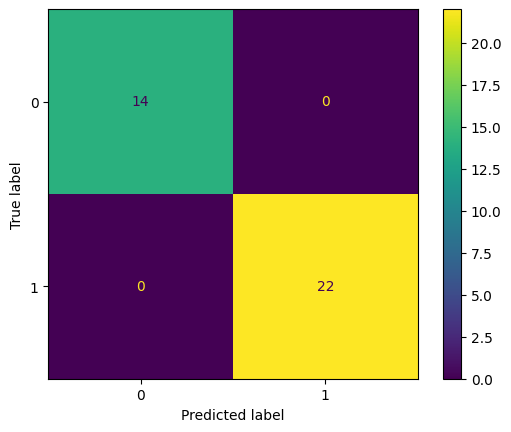

In [ ]:
cm = confusion_matrix(y_test, y_pred_bag)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

## Accuracy Bar Graph

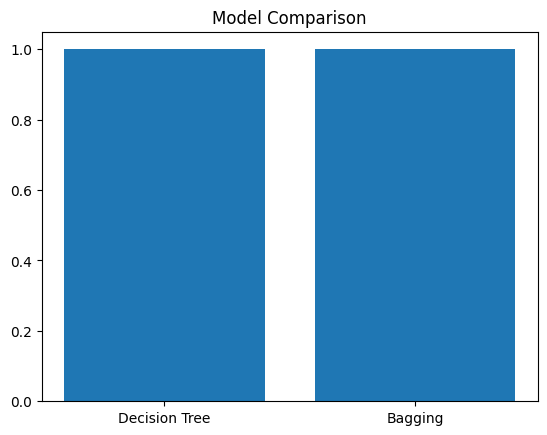

In [ ]:
plt.bar(["Decision Tree","Bagging"], [acc_dt, acc_bag])
plt.title("Model Comparison")
plt.show()